# 03 GIS Change Mapping

## Post-Flood Landscape Change Decision-Support System

This notebook is the GIS integration stage of the workflow.

It takes the Earth Observation products from Stage 1 and the frozen Random Forest outputs from Stage 2 and converts them into spatially aligned GIS products.

### Main objectives

1. Preserve the original EO raster grid and georeferencing.
2. Create an EO-derived change-intensity layer.
3. Reconstruct the EO-derived reference change mask.
4. Convert Random Forest predictions and probabilities into GeoTIFF layers.
5. Generate a full-AOI Random Forest prediction using the frozen model.
6. Produce spatial validation and error maps.
7. Save presentation-ready figures and GIS outputs.

> **Important:** `Y` is an EO-derived/rule-based change target, not independent CEMS ground truth. The Random Forest therefore models and generalizes the EO-defined change pattern rather than independently proving physical flood damage.

## 1. Imports and Project Root

The project root is detected from the notebook location.

The workflow expects the repository structure used by the previous modelling notebook, with EO inputs and ML outputs stored under `Data/` and figures stored under `Figures/`.

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import rasterio
from rasterio.transform import rowcol, xy
from rasterio.plot import plotting_extent
from rasterio.warp import transform_bounds
from pyproj import Transformer

# Resolve project root
NOTEBOOK_DIR=Path.cwd()
if NOTEBOOK_DIR.name.lower() in {"notebooks", "notebook"}:
    PROJECT_ROOT=NOTEBOOK_DIR.parent
else:
      PROJECT_ROOT=NOTEBOOK_DIR
DATA_DIR=PROJECT_ROOT/"Data"
FIG_DIR=PROJECT_ROOT/"Figures"/"03_GIS"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Figure directory:", FIG_DIR)

Project root: c:\Users\User\OneDrive - ST. XAVIER'S COLLEGE\IEEE_NepalFlood
Data directory: c:\Users\User\OneDrive - ST. XAVIER'S COLLEGE\IEEE_NepalFlood\Data
Figure directory: c:\Users\User\OneDrive - ST. XAVIER'S COLLEGE\IEEE_NepalFlood\Figures\03_GIS


## 2. Input and Output Configuration

The GIS stage uses the same EO products and model outputs established by the previous notebooks.

### EO inputs

- `EO_feature_table_labelled.csv`
- `S1_pre.tif`
- `S1_post.tif`
- `S2_indices_change.tif`
- `DEM.tif`

### Random Forest handoff from Notebook 02

- `RF_spatial_test_predictions.csv`
- `random_forest_final.joblib`

The test prediction CSV is used for spatial validation. The saved frozen Random Forest is additionally used to generate a complete-AOI prediction and probability surface from the EO feature table.

In [2]:
# Core EO inputs
FEATURE_CSV=DATA_DIR/"EO_feature_table_labelled.csv"
S1_PRE=DATA_DIR/"S1_pre.tif"
S1_POST=DATA_DIR/"S1_post.tif"
S2_CHANGE=DATA_DIR/"S2_indices_change.tif"
DEM_PATH=DATA_DIR/"DEM.tif"
TEST_PREDICTION_CSV=DATA_DIR/"RF_spatial_test_predictions.csv"
MODEL_FILE=DATA_DIR/"random_forest_final.joblib"
# GIS outputs created by this notebook
EO_CHANGE_TIF=DATA_DIR/"EO_change_intensity.tif"
EO_REFERENCE_TIF=DATA_DIR/"EO_reference_change_mask.tif"
RF_FULL_PRED_TIF=DATA_DIR/"predicted_change.tif"
RF_FULL_PROB_TIF=DATA_DIR/"change_probability.tif"
RF_TEST_PRED_TIF=DATA_DIR/"RF_spatial_test_prediction.tif"
RF_TEST_PROB_TIF=DATA_DIR/"RF_spatial_test_probability.tif"
RF_ERROR_TIF=DATA_DIR/"RF_spatial_test_error.tif"

FULL_PREDICTION_CSV = DATA_DIR / "RF_full_AOI_predictions.csv"
paths=[FEATURE_CSV,S1_PRE,S1_POST,S2_CHANGE,DEM_PATH,TEST_PREDICTION_CSV,MODEL_FILE]
print("Input:")
for p in paths:
    print(f"{p.name:40s} : {p.exists()}")

Input:
EO_feature_table_labelled.csv            : True
S1_pre.tif                               : True
S1_post.tif                              : True
S2_indices_change.tif                    : True
DEM.tif                                  : True
RF_spatial_test_predictions.csv          : True
random_forest_final.joblib               : True


## 4. Load the EO Feature Table

The labelled feature table is the common tabular representation of the aligned EO data.

It contains geographic coordinates, Sentinel-1 SAR variables, Sentinel-2 spectral indices, terrain variables and the EO-derived binary target `Y`.

The table is also used later to generate full-AOI Random Forest predictions using the frozen model from Notebook 02.

In [3]:
if not FEATURE_CSV.exists():
    print(f"Error: {FEATURE_CSV} not found")
else:
    df=pd.read_csv(FEATURE_CSV)
print("Shape:",df.shape)
print("Columns:",df.columns.tolist())
print("\nY distribution:")
print(df["Y"].value_counts())
print("\nCoordinate range:")
print("Longitude:",df["longitude"].min(),"to",df["longitude"].max())
print("Latitude :",df["latitude"].min(),"to",df["latitude"].max())

Shape: (123154, 20)
Columns: ['longitude', 'latitude', 'VV_pre', 'VH_pre', 'VV_post', 'VH_post', 'dVV', 'dVH', 'NDVI_pre', 'NDWI_pre', 'NDBI_pre', 'NDVI_post', 'NDWI_post', 'NDBI_post', 'dNDVI', 'dNDWI', 'dNDBI', 'DEM', 'slope', 'Y']

Y distribution:
Y
0    98523
1    24631
Name: count, dtype: int64

Coordinate range:
Longitude: 84.9614 to 84.99994
Latitude : 28.000217 to 28.24977


## 5. Load the Sentinel-1 Reference Grid

The pre-event Sentinel-1 raster is used as the master spatial grid.

The CRS, affine transform, raster dimensions and profile are retained so that every GIS product generated in this notebook remains spatially aligned with the original EO data.

In [4]:
if not S1_PRE.exists():
    print(f"Error: {S1_PRE} not found")
elif not S1_POST.exists():
    print(f"Error: {S1_POST} not found")
else:
 with rasterio.open(S1_PRE) as src:
    VV_pre=src.read(1).astype("float32")
    VH_pre=src.read(2).astype("float32")
    PROFILE=src.profile.copy()
    TRANSFORM=src.transform
    CRS=src.crs
    HEIGHT=src.height
    WIDTH=src.width
    NODATA=src.nodata
with rasterio.open(S1_POST) as src:
    VV_post=src.read(1).astype("float32")
    VH_post=src.read(2).astype("float32")
print("CRS:",CRS)
print("Raster dimensions:",HEIGHT,"x",WIDTH)
print("Resolution:",PROFILE["transform"].a,abs(PROFILE["transform"].e))

CRS: EPSG:4326
Raster dimensions: 928 x 1114
Resolution: 0.00026949458523585647 0.00026949458523585647


## 6. Derive Sentinel-1 Change Variables

Pre-event and post-event SAR observations are differenced to obtain VV and VH change.

These layers reproduce the SAR change component used in the EO-derived target and the Random Forest feature table.

In [5]:
dVV=VV_post-VV_pre
dVH=VH_post-VH_pre
print("dVV range:",np.nanmin(dVV),"to",np.nanmax(dVV))
print("dVH range:",np.nanmin(dVH),"to",np.nanmax(dVH))

dVV range: -33.61978 to 19.76332
dVH range: -30.49901 to 21.240807


## 7. Load Sentinel-2 Spectral Change Products

The Sentinel-2 product contains aligned pre-event, post-event and change information for NDVI, NDWI and NDBI.

The existing raster is reused so that the GIS stage does not introduce a second index-calculation pathway.

In [6]:
if not S2_CHANGE.exists():
    print(f"Error: {S2_CHANGE} not found")
else:
 with rasterio.open(S2_CHANGE) as src:
    S2=src.read().astype("float32")
print("S2 array shape:",S2.shape)
NDVI_pre=S2[0]
NDWI_pre=S2[1]
NDBI_pre=S2[2]
NDVI_post=S2[3]
NDWI_post=S2[4]
NDBI_post=S2[5]
dNDVI=S2[6]
dNDWI=S2[7]
dNDBI=S2[8]
print("S2 change layers loaded.")

S2 array shape: (9, 928, 1114)
S2 change layers loaded.


## 8. Construct EO-Derived Multi-Sensor Change Intensity

The current target `Y` was generated from standardized absolute changes in `dVV`, `dVH`, `dNDVI` and `dNDWI`.

Here we reconstruct a spatially continuous version of that same change-signal concept.

The result is an **EO-derived change-intensity layer**, not independent ground truth.

In [7]:
def robust_z(x):
    x=x.astype("float32")
    med=np.nanmedian(x)
    mad=np.nanmedian(np.abs(x-med))
    if mad==0 or not np.isfinite(mad):
        return np.zeros_like(x, dtype="float32")
    return (x-med)/(1.4826*mad)
z_dVV=robust_z(dVV)
z_dVH=robust_z(dVH)
z_dNDVI=robust_z(dNDVI)
z_dNDWI=robust_z(dNDWI)
change_intensity=(np.abs(z_dVV)+np.abs(z_dVH)+np.abs(z_dNDVI)+np.abs(z_dNDWI))/4
change_intensity=change_intensity.astype("float32")
print("Change intensity range:",np.nanmin(change_intensity),"to",np.nanmax(change_intensity))

Change intensity range: 0.000246149 to 2.306651


## 9. Save EO Change-Intensity Raster

The EO-derived change-intensity layer is exported as a GeoTIFF using the Sentinel-1 reference profile.

The original CRS, transform, dimensions and pixel alignment are preserved.

In [11]:
# Scale to 0-255 for better visualization in Python
change_intensity_scaled = (change_intensity * 255).astype(np.uint8)
profile_uint8 = PROFILE.copy()
profile_uint8.update(dtype=rasterio.uint8, count=1, nodata=0, compress="lzw")
with rasterio.open(EO_CHANGE_TIF, "w", **profile_uint8) as dst:
    dst.write(change_intensity_scaled, 1)
print("Saved:", EO_CHANGE_TIF)

Saved: c:\Users\User\OneDrive - ST. XAVIER'S COLLEGE\IEEE_NepalFlood\Data\EO_change_intensity.tif


## 10. Map 1 | EO-Derived Landscape Change Intensity

This map shows the spatial magnitude of the multi-sensor EO change signal.

**Question addressed:** Where is the observed EO change signal strongest?

This layer is an EO-derived analytical product and should not be described as independently verified physical damage.

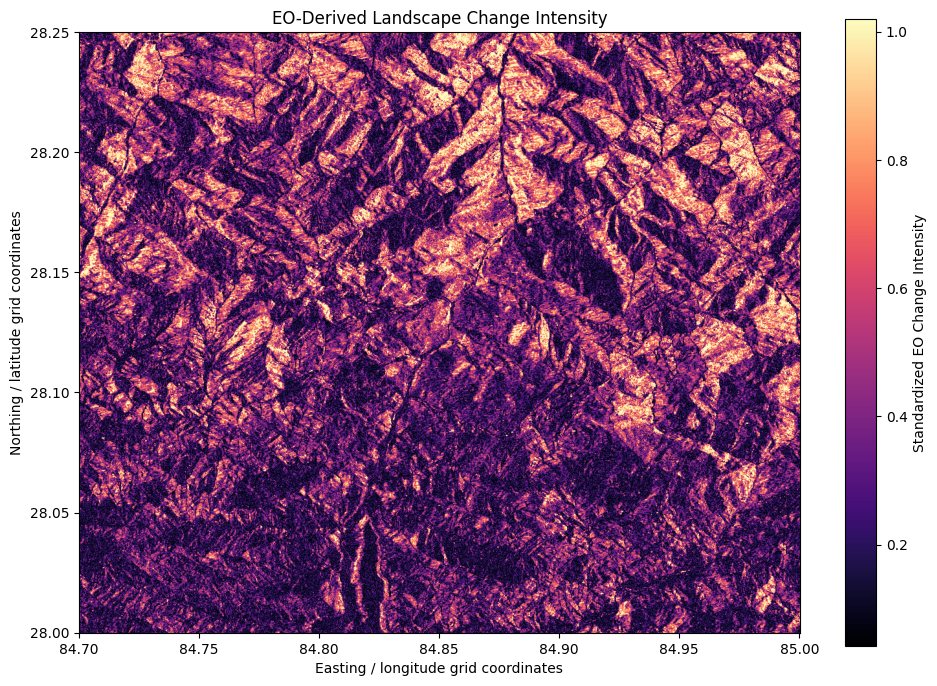

In [10]:
fig,ax=plt.subplots(figsize=(10,7))
vmin,vmax=np.nanpercentile(change_intensity,[2,98])
im=ax.imshow(change_intensity,extent=plotting_extent(change_intensity,TRANSFORM),cmap="magma",vmin=vmin,vmax=vmax)
ax.set_title("EO-Derived Landscape Change Intensity")
ax.set_xlabel("Easting / longitude grid coordinates")
ax.set_ylabel("Northing / latitude grid coordinates")
fig.colorbar(im,ax=ax,label="Standardized EO Change Intensity")
plt.tight_layout()
fig.savefig(FIG_DIR/"EO_change_intensity.png",dpi=300,bbox_inches="tight")
plt.show()

## 11. Convert the EO-Derived Target `Y` to a Spatial Raster

The EO feature table stores longitude and latitude in WGS84.

The raster grid may use a projected CRS, so coordinates are transformed from EPSG:4326 into the Sentinel-1 raster CRS before assigning each observation to its raster cell.

This step creates a georeferenced representation of the exact EO-derived reference target used in modelling.

In [10]:
# Transform WGS84 coordinates from the feature table into the raster CRS
to_raster=Transformer.from_crs("EPSG:4326",CRS,always_xy=True)
x_raster,y_raster=to_raster.transform(df["longitude"].to_numpy(),df["latitude"].to_numpy())
rows, cols=rowcol(TRANSFORM,x_raster,y_raster)
rows=np.asarray(rows)
cols=np.asarray(cols)
y_raster=np.full((HEIGHT,WIDTH),np.nan,dtype="float32")
valid=((rows>=0)&(rows<HEIGHT)&(cols>=0)&(cols<WIDTH))
y_raster[rows[valid],cols[valid]]=df.loc[valid,"Y"].astype("float32")
print("Mapped observations:",int(valid.sum()))
print("Raster Y=0 pixels:",int(np.sum(y_raster==0)))
print("Raster Y=1 pixels:",int(np.sum(y_raster==1)))

Mapped observations: 123154
Raster Y=0 pixels: 50165
Raster Y=1 pixels: 12493


## 12. Save the EO Reference Change Mask

The EO-derived binary target is exported as a GeoTIFF.

This layer is the reference mask used later for spatial agreement and error analysis. It is explicitly a proxy/reference target rather than independent physical ground truth.

In [14]:
profile_float=PROFILE.copy()
profile_float.update(dtype="float32",count=1,nodata=np.nan,compress="lzw")
y_binary = (y_raster > 0.5).astype(np.uint8) * 255
profile_uint8 = profile_float.copy()
profile_uint8.update(dtype=rasterio.uint8, nodata=0)
with rasterio.open(EO_REFERENCE_TIF, "w", **profile_uint8) as dst:
    dst.write(y_binary, 1)
print("Saved (binary mask):", EO_REFERENCE_TIF)

Saved (binary mask): c:\Users\User\OneDrive - ST. XAVIER'S COLLEGE\IEEE_NepalFlood\Data\EO_reference_change_mask.tif


## 13. Map 2 | EO-Derived Reference Change Mask

This binary map displays the spatial distribution of the EO-derived change target.

It provides the reference surface needed to interpret the later Random Forest prediction and error maps.

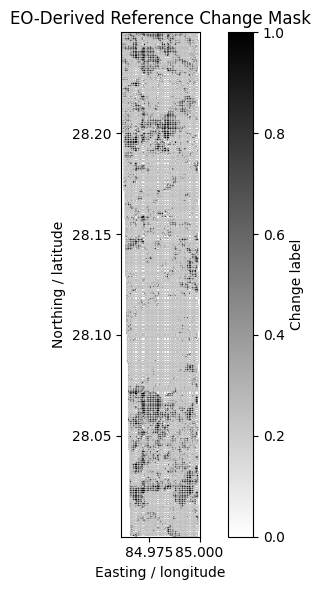

In [23]:
valid_mask= ~np.isnan(y_raster)
rows, cols=np.where(valid_mask)
row_min,row_max=rows.min(), rows.max()
col_min,col_max=cols.min(), cols.max()
cropped_data=y_raster[row_min:row_max+1, col_min:col_max+1]
from rasterio.transform import xy
ul_x,ul_y=xy(TRANSFORM,row_min, col_min)
lr_x,lr_y=xy(TRANSFORM,row_max, col_max)
cropped_extent=[ul_x,lr_x,lr_y,ul_y]
fig, ax=plt.subplots(figsize=(6, 6))
im=ax.imshow(cropped_data,extent=cropped_extent, cmap="gray_r", origin="upper")
ax.set_title("EO-Derived Reference Change Mask")
ax.set_xlabel("Easting / longitude")
ax.set_ylabel("Northing / latitude")
fig.colorbar(im, ax=ax, label="Change label")
plt.tight_layout()
fig.savefig(FIG_DIR/"EO_reference_change_mask.png", dpi=300, bbox_inches="tight")

## 14. Load Random Forest Outputs from Notebook 02

Notebook 02 freezes the Random Forest after spatial cross-validation and performs one final evaluation on the held-out spatial test set.

The GIS stage receives:

- `RF_spatial_test_predictions.csv`
- `random_forest_final.joblib`

The prediction CSV is used for spatial test validation, while the frozen model is used to generate a complete-AOI prediction surface.

In [25]:
if not TEST_PREDICTION_CSV.exists():
    print(f"Error: {TEST_PREDICTION_CSV} not found")
elif not MODEL_FILE.exists():
    print(f"Error: {MODEL_FILE} not found")
else:
 test_pred=pd.read_csv(TEST_PREDICTION_CSV)
frozen_model=joblib.load(MODEL_FILE)
required_cols={"longitude","latitude","Y","Y_pred","P_change"}
missing=required_cols-set(test_pred.columns)
if len(missing) > 0:
    print(f"Error: Missing prediction columns: {missing}")
else:
    print("All required columns present")
print("Spatial test prediction shape:", test_pred.shape)
print("Prediction columns:", test_pred.columns.tolist())
print("\nFrozen model:", type(frozen_model).__name__)

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.9.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


All required columns present
Spatial test prediction shape: (29351, 5)
Prediction columns: ['longitude', 'latitude', 'Y', 'Y_pred', 'P_change']

Frozen model: RandomForestClassifier


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.9.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 15. Generate Full-AOI Random Forest Predictions

The frozen Random Forest from Notebook 02 is applied to every valid row in the EO feature table.

This produces a continuous full-AOI probability surface and a binary predicted-change surface.

These are **inference products**, not a second model-fitting experiment.

In [26]:
FEATURES=["VV_pre", "VH_pre", "VV_post", "VH_post", "dVV", "dVH",
    "NDVI_pre", "NDWI_pre", "NDBI_pre","NDVI_post", "NDWI_post", "NDBI_post","dNDVI", "dNDWI", "dNDBI","DEM", "slope"]
missing_features=set(FEATURES)-set(df.columns)
if len(missing_features) > 0:
    print(f"Error: Missing model features: {missing_features}")
else:
    print("All features present")
X_full=df[FEATURES]
full_pred=frozen_model.predict(X_full)
full_prob=frozen_model.predict_proba(X_full)[:, 1]
full_predictions=df[["longitude", "latitude", "Y"]].copy()
full_predictions["Y_pred"]=full_pred
full_predictions["P_change"]=full_prob
full_predictions.to_csv(FULL_PREDICTION_CSV,index=False)
print("Full-AOI predictions generated:", len(full_predictions))
print("Saved:", FULL_PREDICTION_CSV)

All features present


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Full-AOI predictions generated: 123154
Saved: c:\Users\User\OneDrive - ST. XAVIER'S COLLEGE\IEEE_NepalFlood\Data\RF_full_AOI_predictions.csv


## 16. Rasterize Full-AOI Random Forest Predictions

The full-AOI tabular predictions are mapped onto the original EO grid.

Two continuous spatial products are retained:

- Binary Random Forest prediction
- Random Forest probability of change

The coordinate transformation follows the same WGS84-to-raster-CRS procedure used for the reference mask.

In [27]:
x_full, y_full=to_raster.transform(full_predictions["longitude"].to_numpy(),full_predictions["latitude"].to_numpy())
full_rows,full_cols=rowcol(TRANSFORM,x_full,y_full)
full_rows=np.asarray(full_rows)
full_cols=np.asarray(full_cols)
rf_pred_raster=np.full((HEIGHT,WIDTH),np.nan,dtype="float32")
rf_prob_raster=np.full((HEIGHT,WIDTH),np.nan,dtype="float32")
valid_full=((full_rows>=0)&(full_rows<HEIGHT)&(full_cols>=0)&(full_cols<WIDTH))
rf_pred_raster[full_rows[valid_full],full_cols[valid_full]]=(full_predictions.loc[valid_full,"Y_pred"].astype("float32"))
rf_prob_raster[full_rows[valid_full],full_cols[valid_full]]=(full_predictions.loc[valid_full,"P_change"].astype("float32"))
print("Full-AOI rasterized pixels:", int(valid_full.sum()))

Full-AOI rasterized pixels: 123154


## 17. Save Full-AOI Random Forest GIS Products

The binary prediction and continuous probability surfaces are exported as GeoTIFFs.

These are the principal GIS outputs for the final presentation.

In [28]:
with rasterio.open(RF_FULL_PRED_TIF, "w", **profile_float) as dst:
    dst.write(rf_pred_raster,1)
with rasterio.open(RF_FULL_PROB_TIF, "w", **profile_float) as dst:
    dst.write(rf_prob_raster,1)
print("Saved:", RF_FULL_PRED_TIF)
print("Saved:", RF_FULL_PROB_TIF)

Saved: c:\Users\User\OneDrive - ST. XAVIER'S COLLEGE\IEEE_NepalFlood\Data\predicted_change.tif
Saved: c:\Users\User\OneDrive - ST. XAVIER'S COLLEGE\IEEE_NepalFlood\Data\change_probability.tif


## 18. Map 3 | Full-AOI Random Forest Predicted Change

This map shows where the frozen Random Forest predicts the EO-defined landscape-change pattern across the complete available EO grid.

It is the spatial counterpart to the model's tabular predictions.

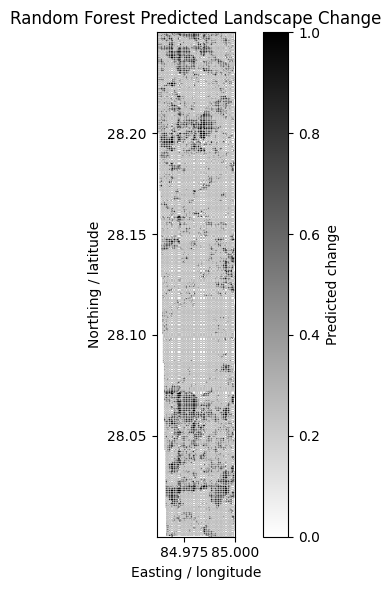

In [29]:
valid_mask=~np.isnan(rf_pred_raster)
rows, cols=np.where(valid_mask)
row_min, row_max=rows.min(),rows.max()
col_min, col_max=cols.min(),cols.max()
cropped_data=rf_pred_raster[row_min:row_max+1,col_min:col_max+1]
ul_x,ul_y=xy(TRANSFORM,row_min,col_min)
lr_x,lr_y=xy(TRANSFORM,row_max,col_max)
cropped_extent=[ul_x,lr_x,lr_y,ul_y]
fig,ax=plt.subplots(figsize=(6,6))
im=ax.imshow(cropped_data,extent=cropped_extent, cmap="gray_r", origin="upper")
ax.set_title("Random Forest Predicted Landscape Change")
ax.set_xlabel("Easting / longitude")
ax.set_ylabel("Northing / latitude")
fig.colorbar(im, ax=ax, label="Predicted change")
plt.tight_layout()
fig.savefig(FIG_DIR/"RF_predicted_change.png", dpi=300, bbox_inches="tight")
plt.show()

## 19. Map 4 | Full-AOI Random Forest Probability of Change

The probability surface retains the model's continuous `P_change` output rather than reducing every pixel to a binary decision.

This map is the main uncertainty-aware spatial product and is a candidate for the final hero map.

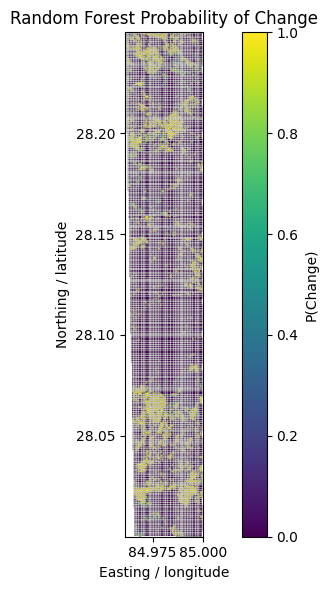

In [30]:
valid_mask=~np.isnan(rf_prob_raster)
rows, cols=np.where(valid_mask)
row_min,row_max=rows.min(),rows.max()
col_min,col_max=cols.min(),cols.max()
cropped_data=rf_prob_raster[row_min:row_max+1,col_min:col_max+1]
ul_x, ul_y=xy(TRANSFORM, row_min, col_min)
lr_x, lr_y=xy(TRANSFORM, row_max, col_max)
cropped_extent=[ul_x, lr_x, lr_y, ul_y]
fig, ax=plt.subplots(figsize=(8, 6))
im = ax.imshow(cropped_data, extent=cropped_extent, cmap="viridis", origin="upper")
ax.set_title("Random Forest Probability of Change")
ax.set_xlabel("Easting / longitude")
ax.set_ylabel("Northing / latitude")
fig.colorbar(im, ax=ax, label="P(Change)")
plt.tight_layout()
fig.savefig(FIG_DIR/"RF_change_probability.png", dpi=300, bbox_inches="tight")
plt.show()


## 20. Spatial Test Predictions as a Validation Raster

The spatial test CSV contains predictions only for the held-out test blocks.

We rasterize these observations separately from the full-AOI prediction so that the validation product does not get confused with the complete-AOI inference map.

In [31]:
test_x, test_y=to_raster.transform(test_pred["longitude"].to_numpy(),test_pred["latitude"].to_numpy())
test_rows,test_cols=rowcol(TRANSFORM,test_x,test_y)
test_rows=np.asarray(test_rows)
test_cols=np.asarray(test_cols)
test_pred_raster=np.full((HEIGHT, WIDTH),np.nan,dtype="float32")
test_prob_raster=np.full((HEIGHT,WIDTH),np.nan,dtype="float32")
valid_test=((test_rows>=0)&(test_rows<HEIGHT)&(test_cols>=0)&(test_cols<WIDTH))
test_pred_raster[test_rows[valid_test],test_cols[valid_test]]=(test_pred.loc[valid_test,"Y_pred"].astype("float32"))
test_prob_raster[test_rows[valid_test],test_cols[valid_test]]=(test_pred.loc[valid_test, "P_change"].astype("float32"))
print("Spatial test pixels rasterized:", int(valid_test.sum()))

Spatial test pixels rasterized: 29351


## 21. Save Spatial Test Prediction Layers

The held-out test prediction and probability layers are saved separately.

These layers support geographic inspection of model generalization without presenting the test subset as a full-AOI prediction.

In [32]:
with rasterio.open(RF_TEST_PRED_TIF,"w",**profile_float) as dst:
    dst.write(test_pred_raster,1)
with rasterio.open(RF_TEST_PROB_TIF,"w",**profile_float) as dst:
    dst.write(test_prob_raster,1)
print("Saved:", RF_TEST_PRED_TIF)
print("Saved:", RF_TEST_PROB_TIF)

Saved: c:\Users\User\OneDrive - ST. XAVIER'S COLLEGE\IEEE_NepalFlood\Data\RF_spatial_test_prediction.tif
Saved: c:\Users\User\OneDrive - ST. XAVIER'S COLLEGE\IEEE_NepalFlood\Data\RF_spatial_test_probability.tif


## 22. Spatial Test Error Map

The held-out test predictions are compared with their corresponding EO-derived `Y` values.

Four agreement states are represented:

- True Negative: reference no-change, predicted no-change
- False Positive: reference no-change, predicted change
- False Negative: reference change, predicted no-change
- True Positive: reference change, predicted change

This is **proxy-label agreement**, not independent physical-damage validation.

In [33]:
# categorical error raster:
# 0 = TN, 1 = FP, 2 = FN, 3 = TP
error_raster=np.full((HEIGHT, WIDTH),np.nan,dtype="float32")
test_y_ref=test_pred["Y"].astype(int).to_numpy()
test_y_hat=test_pred["Y_pred"].astype(int).to_numpy()
error_class=np.select(
    [
        (test_y_ref==0)&(test_y_hat==0),
        (test_y_ref==0)&(test_y_hat==1),
        (test_y_ref==1)&(test_y_hat==0),
        (test_y_ref==1)&(test_y_hat==1)],[0,1,2,3],default=-1)
error_raster[test_rows[valid_test],test_cols[valid_test]]=(error_class[valid_test])
with rasterio.open(RF_ERROR_TIF,"w",**profile_float) as dst:
    dst.write(error_raster,1)
print("Saved:",RF_ERROR_TIF)
print("TN:",np.sum(error_class==0))
print("FP:",np.sum(error_class==1))
print("FN:",np.sum(error_class==2))
print("TP:",np.sum(error_class==3))

Saved: c:\Users\User\OneDrive - ST. XAVIER'S COLLEGE\IEEE_NepalFlood\Data\RF_spatial_test_error.tif
TN: 22821
FP: 380
FN: 78
TP: 6072


## 23. Map 5 | Spatial Test Agreement and Error

This map shows where the frozen Random Forest agrees or disagrees with the EO-derived reference target within the held-out spatial test regions.

The geographic distribution of false positives and false negatives can be inspected alongside terrain, SAR geometry, optical conditions and possible target uncertainty.

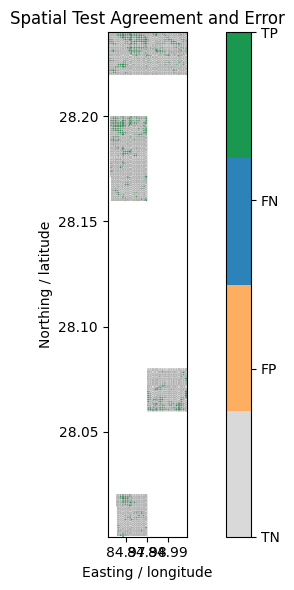

In [ ]:
valid_mask=~np.isnan(error_raster)
rows, cols=np.where(valid_mask)
row_min,row_max=rows.min(),rows.max()
col_min,col_max=cols.min(),cols.max()
cropped_data=error_raster[row_min:row_max+1,col_min:col_max+1]
ul_x,ul_y=xy(TRANSFORM,row_min,col_min)
lr_x,lr_y=xy(TRANSFORM,row_max,col_max)
cropped_extent=[ul_x,lr_x,lr_y,ul_y]
from matplotlib.colors import ListedColormap
cmap_error=ListedColormap(["#d9d9d9", "#fdae61", "#2b83ba", "#1a9850"])
fig,ax=plt.subplots(figsize=(8,6))
im=ax.imshow(cropped_data, extent=cropped_extent, cmap=cmap_error, vmin=0, vmax=3, origin="upper")
ax.set_title("Spatial Test Agreement and Error")
ax.set_xlabel("Easting / longitude")
ax.set_ylabel("Northing / latitude")
cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(["TN", "FP", "FN", "TP"])
plt.tight_layout()
fig.savefig(FIG_DIR/"RF_spatial_test_error.png", dpi=300, bbox_inches="tight")
plt.show()


## 24. GIS Output Audit

The final stage verifies that the expected geospatial products have been written successfully.

All rasters should retain the same dimensions, transform and CRS as the original Sentinel-1 reference grid.

In [ ]:
gis_outputs=[EO_CHANGE_TIF,EO_REFERENCE_TIF,RF_FULL_PRED_TIF,RF_FULL_PROB_TIF,RF_TEST_PRED_TIF,RF_TEST_PROB_TIF,RF_ERROR_TIF]
print("GIS output audit:")
for p in gis_outputs:
    print(f"{p.name:42s} : {p.exists()}")
print("\nRaster alignment:")
for p in gis_outputs:
    if p.exists():
        with rasterio.open(p) as src:
            print(f"{p.name:42s}","shape=",src.shape,"CRS=", src.crs,"transform_match=",src.transform==TRANSFORM)

GIS output audit:
EO_change_intensity.tif                    : True
EO_reference_change_mask.tif               : True
predicted_change.tif                       : True
change_probability.tif                     : True
RF_spatial_test_prediction.tif             : True
RF_spatial_test_probability.tif            : True
RF_spatial_test_error.tif                  : True

Raster alignment:
EO_change_intensity.tif                    shape= (928, 1114) CRS= EPSG:4326 transform_match= True
EO_reference_change_mask.tif               shape= (928, 1114) CRS= EPSG:4326 transform_match= True
predicted_change.tif                       shape= (928, 1114) CRS= EPSG:4326 transform_match= True
change_probability.tif                     shape= (928, 1114) CRS= EPSG:4326 transform_match= True
RF_spatial_test_prediction.tif             shape= (928, 1114) CRS= EPSG:4326 transform_match= True
RF_spatial_test_probability.tif            shape= (928, 1114) CRS= EPSG:4326 transform_match= True
RF_spatial_test_err

# 25. Final GIS Products

The notebook produces:

| Product | Purpose |
|---|---|
| `EO_change_intensity.tif` | Multi-sensor EO change intensity |
| `EO_reference_change_mask.tif` | EO-derived reference change mask |
| `predicted_change.tif` | Full-AOI Random Forest prediction |
| `change_probability.tif` | Full-AOI Random Forest probability |
| `RF_spatial_test_prediction.tif` | Held-out spatial test prediction |
| `RF_spatial_test_probability.tif` | Held-out spatial test probability |
| `RF_spatial_test_error.tif` | Spatial test agreement/error |
| `RF_full_AOI_predictions.csv` | Full-AOI model inference table |
| `Figures/03_GIS/hero_map.png` | Presentation-ready probability map |

### Interpretation guardrail

The current `Y` target is EO-derived and rule-based. The Random Forest therefore demonstrates supervised reproduction/generalization of the EO-defined change pattern across spatially separated regions.

The probability map provides an uncertainty-aware spatial product, while the held-out test error map provides geographic inspection of proxy-label agreement.

No claim is made that the model independently establishes physical flood damage or that `Y` is independent ground truth.